# **Bitcoin Cycle Extremes Forecast: Tops and Bottoms**

A supervised classifier that answers *when*, not *how high*: for every day it estimates the
probability that a cycle **top** (or **bottom**) falls within the next 1 month, 6 months or 1 year.

- **Labels**: the run-up window before each historical extreme. Tops
  2011-06-08, 2013-11-30, 2017-12-17, 2021-11-10, 2025-10-06 - bottoms
  2011-11-19, 2015-01-14, 2018-12-15, 2022-11-21, 2026-07-01.
- **Features**: price technicals, halving-epoch phase, market data (Yahoo), macro (FRED, moved to
  its release date), days since the last top/bottom and the Cycle clock. CoinMetrics on-chain
  fields are left out: its community file lags by months, so they would sit frozen through the
  latest part of the test window.
- **Split**: nothing from `split_date` on is trained on, and nothing fitted to the extremes looks
  past it either - the cycle clock is refitted on the extremes before `split_date`, and an extreme
  only enters "days since last top/bottom" 90 days after it happened. That keeps the 2025 top and
  the 2026 bottom a genuine out-of-sample test: `evaluate_out_of_sample` scores them (AUC + how
  many days the implied date misses the real one).
- **ThermoModel** features are off (`use_thermomodel=False`): `data/thermomodel.csv` is fitted on
  90% of the history, which reaches into the test window.
- **Output**: `output/0.Forecast_Tops.jpg` (tops) and
  `output/0.Forecast_Bottoms.jpg` (bottoms), saved by the pipeline itself. A forecast line
  is only drawn while it is still open: a signal already answered by a labelled extreme is not
  shown as the prediction of a further one.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import sys, os
_base = os.getcwd()
while _base and not os.path.isdir(os.path.join(_base, 'functions')):
    _parent = os.path.dirname(_base)
    if _parent == _base: break
    _base = _parent
if os.path.abspath(_base) not in sys.path:
    sys.path.insert(0, os.path.abspath(_base))
from functions.functions_Forecast import run_bitcoin_forecast

PARAMS = dict(
    load_markets=True,
    load_fred=True,
    use_thermomodel=False,  # leaks the test window, see above
    use_cycles=True,
    data_folder=os.path.join(_base, "data"),
    activation_threshold=0.9,
    split_date="2024-01-01",
)

🚀 Starting Bitcoin Cycle Top Forecasting...
🚀 LOADING RAW DATA SOURCES
₿ Loading Bitcoin data...


✅ BTC data fetched from CoinMetrics: 6351 rows (last: 2026-05-24)


🔄 BTC PriceUSD topped up with Yahoo Finance through 2026-09-23 (123 extra day(s)); other on-chain fields carried forward from 2026-05-23
✅ Bitcoin data loaded: 5912 rows
📈 Loading market data...


✅ Market data loaded: 8/8 tickers
✅ Market data merged: 8 indicators
🏦 Loading FRED economic data...


✅ FRED data loaded: 6/6 series
✅ FRED data merged: 8 indicators
🔄 Fitting the cycle clock...
✅ Cycle clock refitted on extremes before 2024-01-01: period 1445 days, first top after it on 2025-11-07
✅ Cycles merged: 13 features
✅ Bitcoin technical indicators added
🎯 Final raw dataset shape: (5912, 37)

🎯 Generating targets...
✅ Target variables generated (5 tops labelled)

⚙️ Engineering features...
✅ Feature engineering completed: 108 features

🔧 Reducing features...


...

✅ Target_6M - CV AUC: 0.559 ± 0.362
   📊 gb_conservative: 0.560 ± 0.364
   📊 gb_aggressive: 0.640 ± 0.230

🎯 Training Target_1Y...
   Class distribution: 3495 negative, 1420 positive (pos: 28.9%)
Creating fixed splits for Target_1Y:
  Total samples: 4915
  Positive samples: 1420
  Positive ratio: 28.9%
  Split 1: Train=914, Val=1785
    Train pos: 373, Val pos: 672
    Val pos ratio: 37.6%
  Split 2: Train=2500, Val=1732
    Train pos: 846, Val pos: 574
    Val pos ratio: 33.1%


✅ Fold 0 completed - AUC: 0.802


✅ Fold 1 completed - AUC: 0.893
📊 Completed 2/2 folds successfully


✅ Target_1Y - CV AUC: 0.847 ± 0.046
   📊 gb_conservative: 0.895 ± 0.086
   📊 gb_aggressive: 0.800 ± 0.005

🔄 APPLYING TEMPORAL LOGIC CONSTRAINTS
   📊 264 day(s) with a shorter horizon above a longer one → capped
✅ Model training completed successfully!

📈 Model Performance Summary:

Target_1M:
  Ensemble CV AUC: 0.766 ± 0.205
  gb_conservative CV AUC: 0.766 ± 0.205
  gb_aggressive CV AUC: 0.765 ± 0.206

Target_6M:
  Ensemble CV AUC: 0.559 ± 0.362
  gb_conservative CV AUC: 0.560 ± 0.364
  gb_aggressive CV AUC: 0.640 ± 0.230

Target_1Y:
  Ensemble CV AUC: 0.847 ± 0.046
  gb_conservative CV AUC: 0.895 ± 0.086
  gb_aggressive CV AUC: 0.800 ± 0.005

📊 Creating visualizations...
📅 Target_1Y forecast: threshold crossed 2024-12-16 → Top predicted 2025-12-16 (already resolved by the 2025-10-06 top)
📅 Target_6M forecast: threshold crossed 2025-06-19 → Top predicted 2025-12-16 (already resolved by the 2025-10-06 top)


💾 Saved /Users/danyr92/Coding/bitcoin_datascience/output/0.Forecast_Tops.jpg


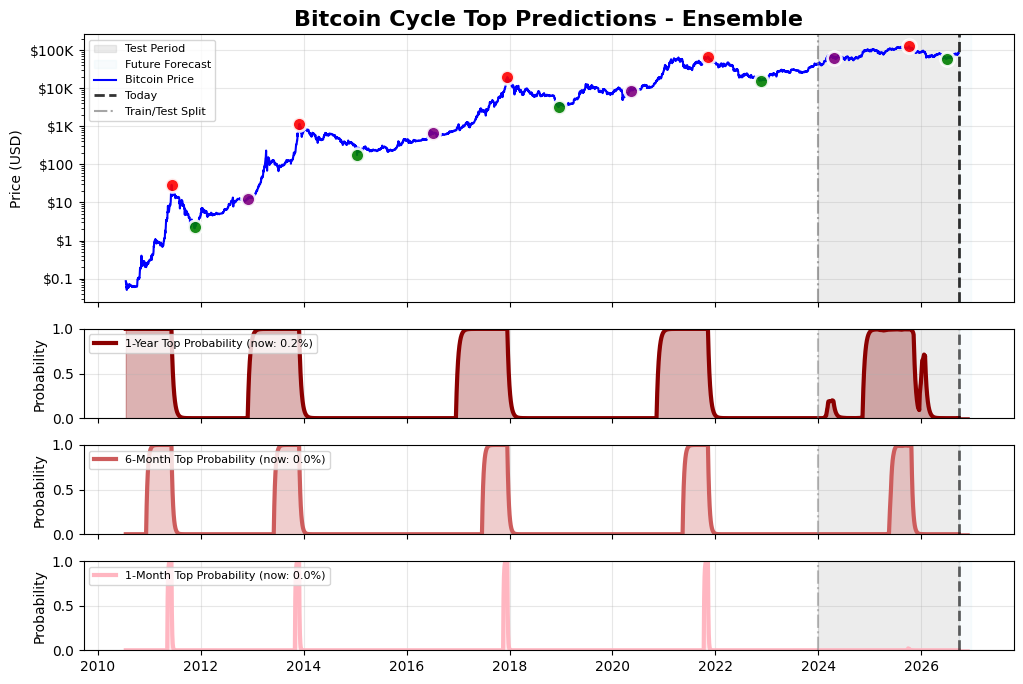

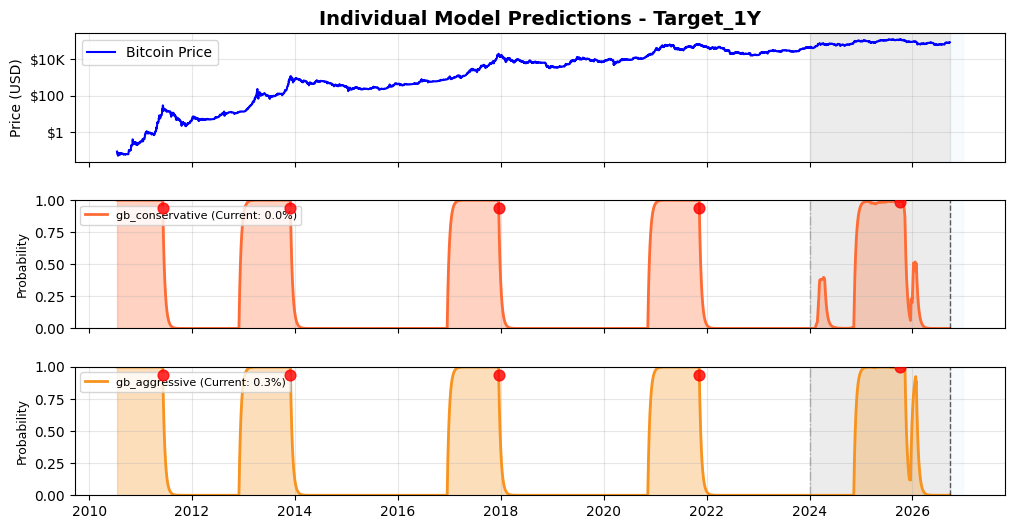

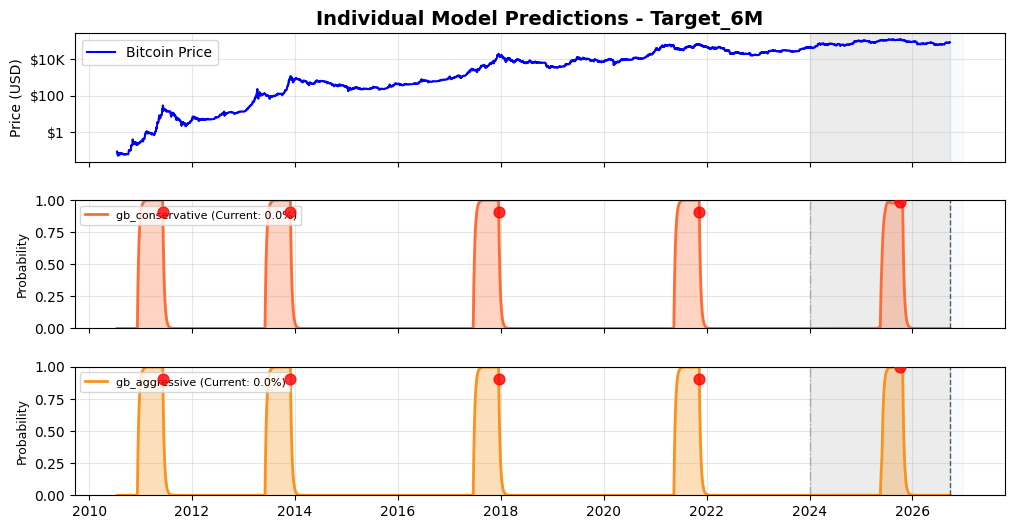

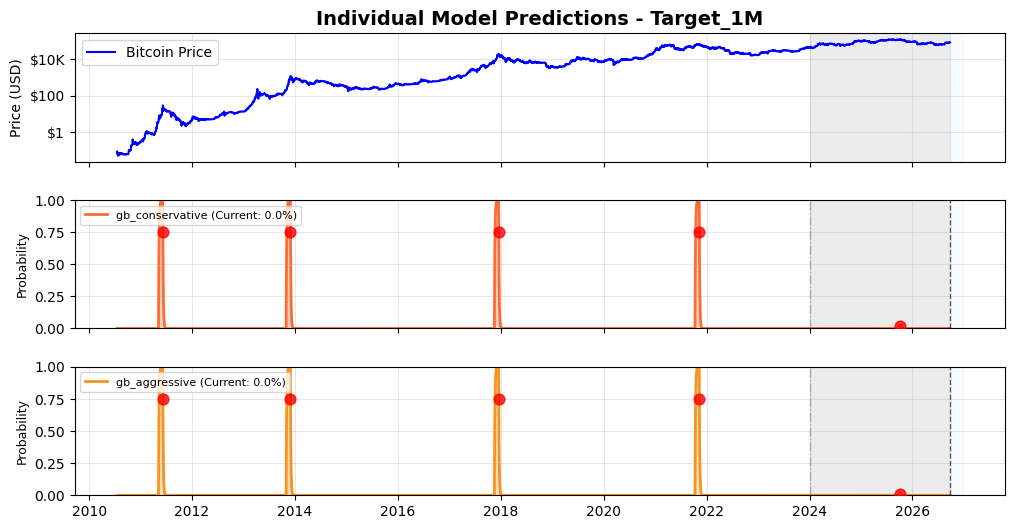


🧪 Showing confusion matrices from Cross-Validation...


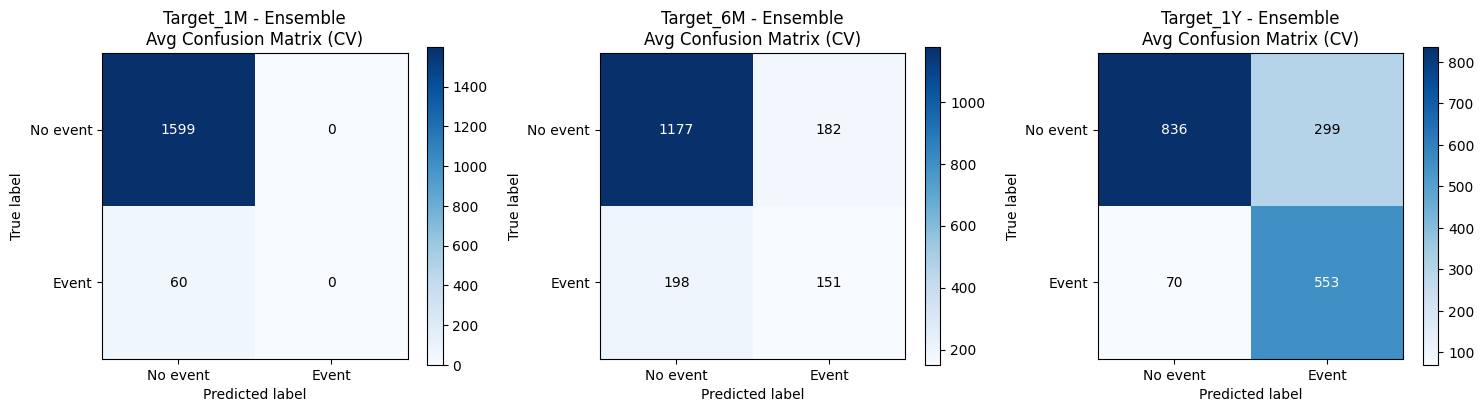


📊 CONFUSION MATRIX SUMMARY (from Cross-Validation):

🎯 Target_1M - Ensemble (averaged over 2 CV folds):
   True Negatives: 1599.5
   False Positives: 0.5
   False Negatives: 60.0
   True Positives: 0.0
   Precision: 0.000
   Recall: 0.000

   📊 gb_conservative:
      TN: 1599.5, FP: 0.5, FN: 60.0, TP: 0.0

   📊 gb_aggressive:
      TN: 1599.5, FP: 0.5, FN: 60.0, TP: 0.0

🎯 Target_6M - Ensemble (averaged over 2 CV folds):
   True Negatives: 1177.5
   False Positives: 182.5
   False Negatives: 198.5
   True Positives: 151.5
   Precision: 0.454
   Recall: 0.433

   📊 gb_conservative:
      TN: 1270.0, FP: 90.0, FN: 299.5, TP: 50.5

   📊 gb_aggressive:
      TN: 1172.5, FP: 187.5, FN: 198.5, TP: 151.5

🎯 Target_1Y - Ensemble (averaged over 2 CV folds):
   True Negatives: 836.5
   False Positives: 299.0
   False Negatives: 70.0
   True Positives: 553.0
   Precision: 0.649
   Recall: 0.888

   📊 gb_conservative:
      TN: 836.5, FP: 299.0, FN: 69.5, TP: 553.5

   📊 gb_aggressive:
      TN: 

💾 Saved /Users/danyr92/Coding/bitcoin_datascience/data/0.Forecast_predictions_tops.csv (6002 rows)

🧾 OUT-OF-SAMPLE CHECK (tops, test from 2024-01-01)
   Actual top(s) in test: 2025-10-06
   Target_1Y  AUC 0.909 | fired 2024-12-16 → top on 2025-12-16 | actual 2025-10-06 | miss +71d
              confirmed 2025-11-18 | miss +43d
   Target_6M  AUC 0.953 | fired 2025-06-19 → top on 2025-12-16 | actual 2025-10-06 | miss +71d
              confirmed 2025-10-31 | miss +25d
   Target_1M  AUC 0.966 | never crossed 90% in test
   ➜ median |timing error|, fired:     71 days over 2 horizon(s)
   ➜ median |timing error|, confirmed: 34 days over 2 horizon(s)

🚀 BITCOIN CYCLE TOP FORECAST - ENHANCED
💰 Current Price: $84,317
⛏️ Next Halving: 575 days (est. 2028-04-20)

📅 CYCLE TOP FORECASTS (Threshold: 90%, latest crossing in the test window):
   ✔️ 1-Year: fired 2024-12-16, answered by the 2025-10-06 top - no open forecast
   ✔️ 6-Month: fired 2025-06-19, answered by the 2025-10-06 top - no open for

In [2]:
tops = run_bitcoin_forecast(side="top", **PARAMS)

🚀 Starting Bitcoin Cycle Bottom Forecasting...
♻️ Reusing the raw data already loaded today

🎯 Generating targets...
✅ Target variables generated (5 bottoms labelled)

⚙️ Engineering features...
✅ Feature engineering completed: 108 features

🔧 Reducing features...


🔧 Features reduced: 108 → 78

🤖 Training models...



🎯 Training Target_1M...
   Class distribution: 4795 negative, 120 positive (pos: 2.4%)
Creating fixed splits for Target_1M:
  Total samples: 4915
  Positive samples: 120
  Positive ratio: 2.4%
  Split 0: Train=359, Val=1361
    Train pos: 0, Val pos: 60
    Val pos ratio: 4.4%
    Skipping split 0 (insufficient class diversity)
  Split 1: Train=1521, Val=1640
    Train pos: 30, Val pos: 60
    Val pos ratio: 3.7%
  Split 2: Train=2962, Val=1646
    Train pos: 60, Val pos: 60
    Val pos ratio: 3.6%


✅ Fold 0 completed - AUC: 0.455


✅ Fold 1 completed - AUC: 0.678
📊 Completed 2/2 folds successfully


...

✅ Target_6M - CV AUC: 0.744 ± 0.232
   📊 gb_conservative: 0.744 ± 0.232
   📊 gb_aggressive: 0.737 ± 0.237

🎯 Training Target_1Y...
   Class distribution: 3455 negative, 1460 positive (pos: 29.7%)
Creating fixed splits for Target_1Y:
  Total samples: 4915
  Positive samples: 1460
  Positive ratio: 29.7%
  Split 1: Train=1297, Val=1751
    Train pos: 386, Val pos: 685
    Val pos ratio: 39.1%
  Split 2: Train=2849, Val=1759
    Train pos: 872, Val pos: 588
    Val pos ratio: 33.4%


✅ Fold 0 completed - AUC: 0.553


✅ Fold 1 completed - AUC: 0.983
📊 Completed 2/2 folds successfully


✅ Target_1Y - CV AUC: 0.768 ± 0.215
   📊 gb_conservative: 0.769 ± 0.214
   📊 gb_aggressive: 0.767 ± 0.214

🔄 APPLYING TEMPORAL LOGIC CONSTRAINTS
   📊 64 day(s) with a shorter horizon above a longer one → capped
✅ Model training completed successfully!

📈 Model Performance Summary:

Target_1M:
  Ensemble CV AUC: 0.566 ± 0.112
  gb_conservative CV AUC: 0.566 ± 0.111
  gb_aggressive CV AUC: 0.626 ± 0.123

Target_6M:
  Ensemble CV AUC: 0.744 ± 0.232
  gb_conservative CV AUC: 0.744 ± 0.232
  gb_aggressive CV AUC: 0.737 ± 0.237

Target_1Y:
  Ensemble CV AUC: 0.768 ± 0.215
  gb_conservative CV AUC: 0.769 ± 0.214
  gb_aggressive CV AUC: 0.767 ± 0.214

📊 Creating visualizations...
📅 Target_1Y forecast: threshold crossed 2025-12-10 → Bottom predicted 2026-12-10 (already resolved by the 2026-07-01 bottom)
📅 Target_6M forecast: threshold crossed 2026-06-15 → Bottom predicted 2026-12-12 (already resolved by the 2026-07-01 bottom)


💾 Saved /Users/danyr92/Coding/bitcoin_datascience/output/0.Forecast_Bottoms.jpg


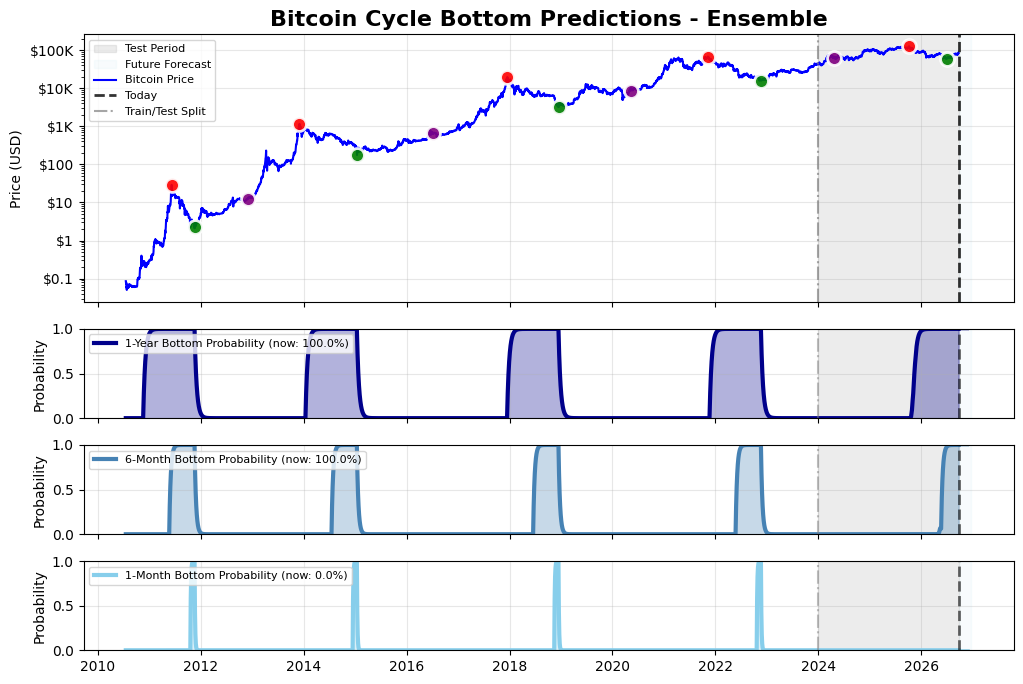

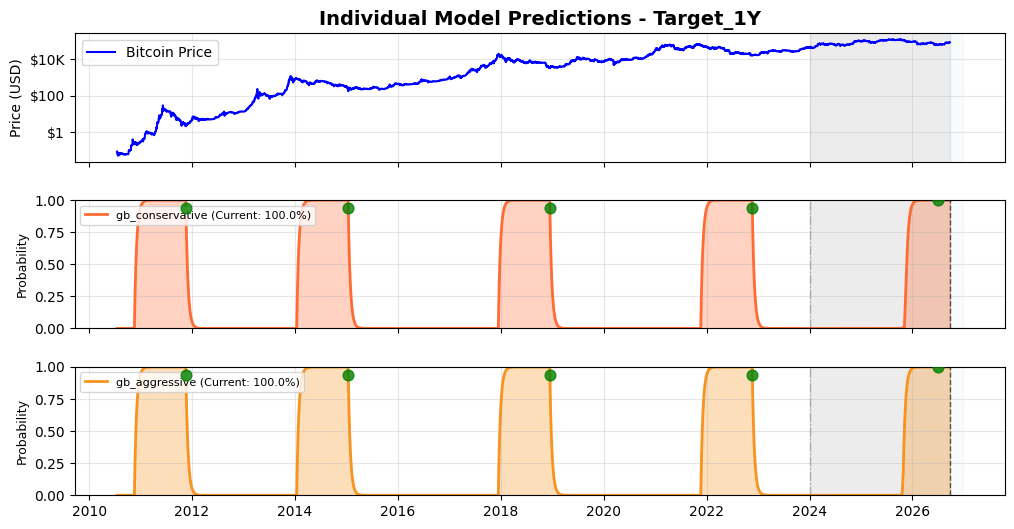

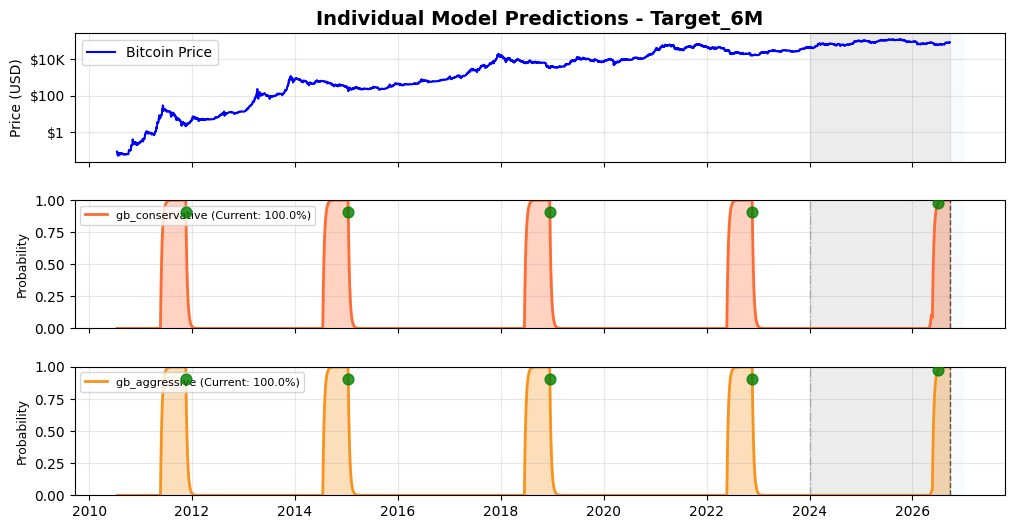

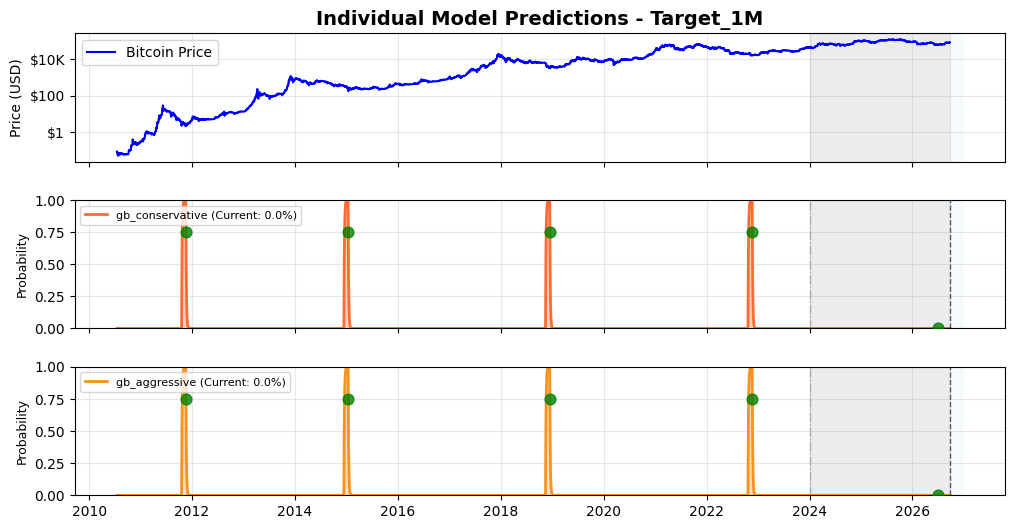


🧪 Showing confusion matrices from Cross-Validation...


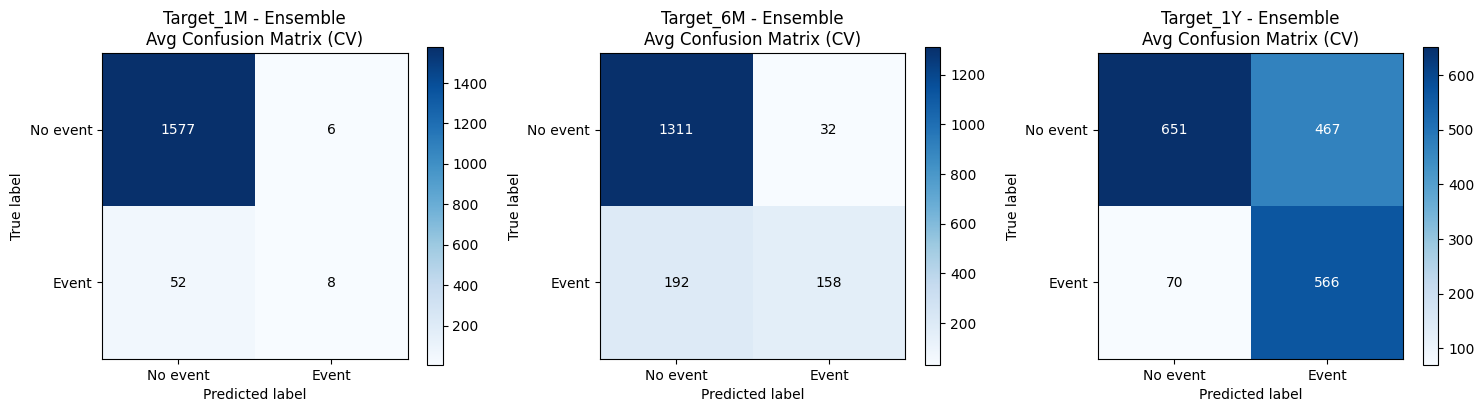


📊 CONFUSION MATRIX SUMMARY (from Cross-Validation):

🎯 Target_1M - Ensemble (averaged over 2 CV folds):
   True Negatives: 1577.0
   False Positives: 6.0
   False Negatives: 52.0
   True Positives: 8.0
   Precision: 0.571
   Recall: 0.133

   📊 gb_conservative:
      TN: 1576.0, FP: 7.0, FN: 52.0, TP: 8.0

   📊 gb_aggressive:
      TN: 1582.0, FP: 1.0, FN: 57.5, TP: 2.5

🎯 Target_6M - Ensemble (averaged over 2 CV folds):
   True Negatives: 1311.0
   False Positives: 32.0
   False Negatives: 192.0
   True Positives: 158.0
   Precision: 0.832
   Recall: 0.451

   📊 gb_conservative:
      TN: 1311.0, FP: 32.0, FN: 192.0, TP: 158.0

   📊 gb_aggressive:
      TN: 1311.0, FP: 32.0, FN: 192.0, TP: 158.0

🎯 Target_1Y - Ensemble (averaged over 2 CV folds):
   True Negatives: 651.5
   False Positives: 467.0
   False Negatives: 70.5
   True Positives: 566.0
   Precision: 0.548
   Recall: 0.889

   📊 gb_conservative:
      TN: 656.5, FP: 462.0, FN: 70.5, TP: 566.0

   📊 gb_aggressive:
      TN: 6

💾 Saved /Users/danyr92/Coding/bitcoin_datascience/data/0.Forecast_predictions_bottoms.csv (6002 rows)

🧾 OUT-OF-SAMPLE CHECK (bottoms, test from 2024-01-01)
   Actual bottom(s) in test: 2026-07-01
   Target_1Y  AUC 0.850 | fired 2025-12-10 → bottom on 2026-12-10 | actual 2026-07-01 | miss +162d
   Target_6M  AUC 0.896 | fired 2026-06-15 → bottom on 2026-12-12 | actual 2026-07-01 | miss +164d
   Target_1M  AUC 0.210 | never crossed 90% in test
   ➜ median |timing error|, fired:     163 days over 2 horizon(s)

🚀 BITCOIN CYCLE BOTTOM FORECAST - ENHANCED
💰 Current Price: $84,317
⛏️ Next Halving: 575 days (est. 2028-04-20)

📅 CYCLE BOTTOM FORECASTS (Threshold: 90%, latest crossing in the test window):
   ✔️ 1-Year: fired 2025-12-10, answered by the 2026-07-01 bottom - no open forecast
   ✔️ 6-Month: fired 2026-06-15, answered by the 2026-07-01 bottom - no open forecast
   ⏳ 1-Month: Threshold not reached in the test window
🔄 Cycle Model Status: 📉 LOW
🧠 Enhanced with: 🔄 CycleModel

📊 CURRENT

In [3]:
bottoms = run_bitcoin_forecast(side="bottom", **PARAMS)